# Disordered Transport and Wavepacket Localization

This notebook compares the spreading of a localized excitation in clean and disordered tight-binding chains. It uses the package's coherent Hamiltonian simulation workflow to validate return probability and mean-square displacement against exact spectral evolution at several times.

## Notebook guide

- **Learning objective:** validate finite-chain transport observables with coherent QSVT.
- **Prerequisites:** an editable repository install, the relevant tutorial workflow, and basic spectral linear algebra.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](10_thermal_heisenberg_chain.ipynb).


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** An excitation hops between adjacent sites of an open, eight-site chain. Fixed random site energies scatter the excitation; comparing zero and nonzero disorder illustrates how disorder can suppress spatial spreading.

**QSVT implementation.** `hamiltonian_simulation_workflow` designs cosine and sine polynomials, synthesizes their phases, and combines their finite QSVT circuits coherently. All QSVT markers below come from executed circuits, conditioned on logical postselection. Dense spectral reference curves are calculated independently in the notebook.

**Classical reference and quantum relevance.** Exact diagonalization supplies the reference time evolution and transport observables. This extends the single-time dynamics example to observable-level validation across time and disorder. Dense matrix embedding and statevector simulation keep the example auditable; they do not establish efficient Hamiltonian access or a quantum speedup.

## Variable definitions

- $H=-J\sum_{j=0}^{N-2}(|j\rangle\langle j+1|+|j+1\rangle\langle j|)+\sum_j\epsilon_j|j\rangle\langle j|$ is the open-chain Hamiltonian with $N$ sites and hopping $J$.
- $\epsilon_j=Wv_j$, with seeded $v_j\in[-1/2,1/2]$, are site energies; $W$ is the disorder width.
- $|\psi_0\rangle=|j_0\rangle$ is the initial localized excitation, and $|\psi(t)\rangle=e^{-iHt}|\psi_0\rangle$; $\hbar=J=1$ and the lattice spacing is one.
- $p_j(t)=|\langle j|\psi(t)\rangle|^2$ is the site probability, normalized after logical postselection for circuit outputs.
- $R(t)=p_{j_0}(t)$ is the return probability and $M_2(t)=\sum_j(j-j_0)^2p_j(t)$ is the mean-square displacement from the initial site.
- $A=(H-cI)/s$ is the scaled signal operator, with offset $c$, scale $s$, and scaled time $\tau=st$.
- $d$ is the polynomial degree limit; $p_{\mathrm{success}}$ is the circuit's logical postselection probability, distinct from $R(t)$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from notebooks._support import display_table
from qsvt.stable import hamiltonian_simulation_workflow

np.set_printoptions(precision=4, suppress=True)

## Finite chain and reproducible disorder

The same seeded site-energy pattern is multiplied by each disorder width. This paired comparison isolates the change in disorder strength for one realization. The time window is short and the chain small; an ensemble or system-size study would answer a different question.

In [2]:
n_sites = 8
initial_site = 3
hopping = 1.0
SEED = 0
disorder_widths = (0.0, 6.0)
circuit_times = np.array([0.4, 0.8, 1.2])
reference_times = np.linspace(0.0, circuit_times[-1], 121)
degree = 19
acceptance_tolerance = 1e-6
observable_tolerance = 1e-4

sites = np.arange(n_sites)
distance_squared = (sites - initial_site) ** 2
site_pattern = np.random.default_rng(SEED).uniform(-0.5, 0.5, n_sites)
initial_state = np.zeros(n_sites, dtype=complex)
initial_state[initial_site] = 1.0
kinetic = -hopping * (np.eye(n_sites, k=1) + np.eye(n_sites, k=-1))
hamiltonians = {
    width: kinetic + np.diag(width * site_pattern)
    for width in disorder_widths
}
print(f"sites: {n_sites}; initial site: {initial_site}; disorder seed: {SEED}")
print(f"disorder widths: {disorder_widths}; polynomial degree limit: {degree}")
print(f"disordered site energies: {disorder_widths[-1] * site_pattern}")

sites: 8; initial site: 3; disorder seed: 42
disorder widths: (0.0, 6.0); polynomial degree limit: 19
disordered site energies: [ 1.6437 -0.3667  2.1516  1.1842 -2.4349  2.8537  1.5668  1.7164]


## Exact transport reference

Diagonalization is used only as a classical validation reference. Return probability and displacement depend on site probabilities, so the physically irrelevant global phase from affine Hamiltonian rescaling cancels.

In [3]:
reference_probabilities = {}
reference_at_circuit_times = {}
for width, hamiltonian in hamiltonians.items():
    energies, eigenvectors = np.linalg.eigh(hamiltonian)
    amplitudes = eigenvectors.conj().T @ initial_state

    def exact_probabilities(times):
        states = eigenvectors @ (
            np.exp(-1j * energies[:, None] * times[None, :])
            * amplitudes[:, None]
        )
        return np.abs(states.T) ** 2

    reference_probabilities[width] = exact_probabilities(reference_times)
    reference_at_circuit_times[width] = exact_probabilities(circuit_times)
    np.testing.assert_allclose(
        reference_probabilities[width].sum(axis=1), 1.0, atol=1e-12
    )
    np.testing.assert_allclose(
        reference_probabilities[width][0], np.abs(initial_state) ** 2, atol=1e-12
    )

## Executed QSVT transport and error ledger

Each selected time runs the public workflow with dense embedding on `default.qubit` in statevector mode. The conditional probabilities below are derived from `qsvt_execution.logical_output`, not the dense polynomial state. Package acceptance, polynomial error, phase reconstruction, circuit agreement, and observable errors are checked separately. These deterministic simulator checks contain no finite-shot uncertainty.

In [4]:
simulations = {}
circuit_probabilities = {}
rows = []
for width, hamiltonian in hamiltonians.items():
    probabilities = []
    for index, time in enumerate(circuit_times):
        result = hamiltonian_simulation_workflow(
            hamiltonian,
            initial_state,
            time=float(time),
            degree=degree,
            acceptance_tolerance=acceptance_tolerance,
            phase_reconstruction_tolerance=1e-6,
            block_encoding="embedding",
            execute_qsvt=True,
        )
        execution = result.qsvt_execution
        assert execution is not None and execution.succeeded, (
            None if execution is None else execution.error
        )
        assert execution.logical_output is not None
        report = result.as_report()
        assert report["acceptance"]["full_qsvt_acceptance"], report["acceptance"]
        p = np.abs(execution.logical_output) ** 2
        p /= p.sum()
        exact = reference_at_circuit_times[width][index]
        polynomial_p = np.abs(result.evolved_state) ** 2
        polynomial_p /= polynomial_p.sum()
        np.testing.assert_allclose(
            np.abs(result.reference_state) ** 2, exact, atol=1e-12
        )
        return_error = abs(p[initial_site] - exact[initial_site])
        displacement_error = abs(distance_squared @ (p - exact))
        assert return_error < observable_tolerance
        assert displacement_error < observable_tolerance
        assert 0.0 < execution.logical_success_probability <= 1.0
        simulations[(width, float(time))] = result
        probabilities.append(p)
        rows.append({
            "W": width,
            "t": time,
            "return": p[initial_site],
            "displacement": distance_squared @ p,
            "return_error": return_error,
            "displacement_error": displacement_error,
            "polynomial_probability_error": np.max(np.abs(polynomial_p - exact)),
            "phase_error": result.component_error_ledger["phase_reconstruction_max_error"],
            "circuit_error": execution.logical_output_relative_error,
            "success": execution.logical_success_probability,
            "accepted": report["acceptance"]["full_qsvt_acceptance"],
        })
    circuit_probabilities[width] = np.asarray(probabilities)

display_table(
    "Transport observables from conditional QSVT output",
    rows,
    [(name, lambda row, key=name: row[key]) for name in (
        "W", "t", "return", "displacement", "return_error", "displacement_error"
    )],
    layout="rows",
)
display_table(
    "Independent polynomial, synthesis, circuit, and acceptance evidence",
    rows,
    [(name, lambda row, key=name: row[key]) for name in (
        "W", "t", "polynomial_probability_error", "phase_error",
        "circuit_error", "success", "accepted"
    )],
    layout="rows",
)
print("observable validation: passed")

Transport observables from conditional QSVT output
--------------------------------------------------
W  t    return    displacement  return_error  displacement_error
-  ---  --------  ------------  ------------  ------------------
0  0.4  0.7162    0.32          5.25e-08      4.40e-08          
0  0.8  0.2074    1.279         8.55e-08      2.98e-07          
0  1.2  5.85e-06  2.854         2.81e-14      1.13e-07          
6  0.4  0.7398    0.2924        2.42e-08      2.33e-08          
6  0.8  0.3863    0.9344        2.50e-09      1.98e-09          
6  1.2  0.2304    1.65          4.27e-08      3.00e-09          
Independent polynomial, synthesis, circuit, and acceptance evidence
-------------------------------------------------------------------
W  t    polynomial_probability_error  phase_error  circuit_error  success  accepted
-  ---  ----------------------------  -----------  -------------  -------  --------
0  0.4  1.33e-15                      1.67e-07     7.60e-08       0.3531  

## Transport observables and final site distribution

Solid lines show exact spectral references; circles show executed QSVT results at the selected times. The final panel compares the conditional site distributions directly. No smooth curve is inferred from the sparse circuit samples.

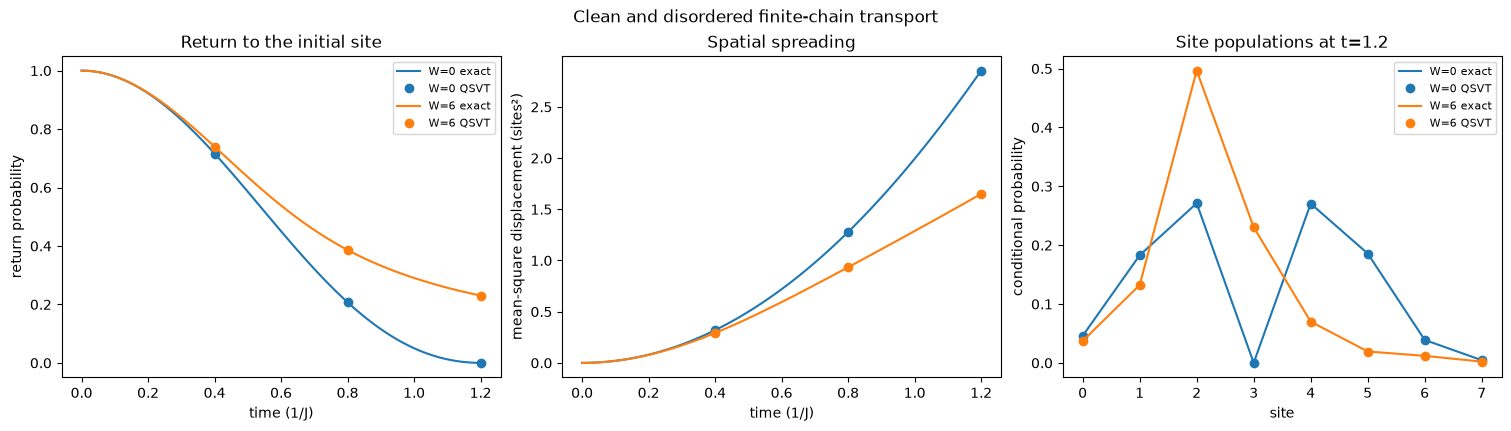

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for width, color in zip(disorder_widths, ("tab:blue", "tab:orange")):
    label = f"W={width:g}"
    exact = reference_probabilities[width]
    circuit = circuit_probabilities[width]
    axes[0].plot(reference_times, exact[:, initial_site], color=color, label=f"{label} exact")
    axes[0].plot(circuit_times, circuit[:, initial_site], "o", color=color, label=f"{label} QSVT")
    axes[1].plot(reference_times, exact @ distance_squared, color=color)
    axes[1].plot(circuit_times, circuit @ distance_squared, "o", color=color)
    axes[2].plot(sites, exact[-1], "-", color=color, label=f"{label} exact")
    axes[2].plot(sites, circuit[-1], "o", color=color, label=f"{label} QSVT")
axes[0].set(xlabel="time (1/J)", ylabel="return probability", title="Return to the initial site")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="time (1/J)", ylabel="mean-square displacement (sites²)", title="Spatial spreading")
axes[2].set(xlabel="site", ylabel="conditional probability", title=f"Site populations at t={circuit_times[-1]:g}")
axes[2].set_xticks(sites)
axes[2].legend(fontsize=8)
fig.suptitle("Clean and disordered finite-chain transport")
plt.show()

## Circuit resources and postselection

The package resource ledger below belongs to the final-time circuit for each chain. Logical signal calls and simulator circuit resources are distinct from hardware compilation costs. Postselection probability is printed alongside the observables above; conditioning the site probabilities does not remove that cost.

In [6]:
for width in disorder_widths:
    result = simulations[(width, float(circuit_times[-1]))]
    print(f"W={width:g}, t={result.time:g}")
    print(f"signal offset: {result.scaled_operator.offset:.6f}")
    print(f"signal scale: {result.scaled_operator.scale:.6f}")
    print(f"scaled time: {result.scaled_time:.6f}")
    print(f"polynomial operator relative error: {result.operator_relative_error:.3e}")
    print(f"polynomial norm drift: {result.norm_drift:.3e}")
    resources = result.circuit_resource_ledger
    display_table(
        "Logical circuit resources (before hardware decomposition)",
        [{"field": key, "value": resources[key]} for key in (
            "total_wire_count", "total_phase_count", "total_signal_operator_calls",
            "num_gates", "depth", "logical_success_probability", "omitted_costs"
        )],
        [("field", lambda row: row["field"]), ("value", lambda row: row["value"])],
        layout="rows",
    )
    print()

clean_m2 = reference_probabilities[0.0][-1] @ distance_squared
disordered_m2 = reference_probabilities[6.0][-1] @ distance_squared
print(f"Final exact displacement: clean={clean_m2:.6f}, disordered={disordered_m2:.6f}")
print(f"Largest return-probability error: {max(row['return_error'] for row in rows):.3e}")
print(f"Largest displacement error: {max(row['displacement_error'] for row in rows):.3e}")

W=0, t=1.2
signal offset: -0.000000
signal scale: 1.879385
scaled time: 2.255262
polynomial operator relative error: 2.700e-15
polynomial norm drift: 8.882e-16
Logical circuit resources (before hardware decomposition)
---------------------------------------------------------
field                        value                                                                                                                                                   
---------------------------  --------------------------------------------------------------------------------------------------------------------------------------------------------
total_wire_count             6                                                                                                                                                       
total_phase_count            78                                                                                                                                                   

## Interpretation and limitations

The clean/disordered comparison describes one seeded realization on eight sites over a short time window. Reduced spreading is a finite-time signature consistent with localization physics, not evidence for a thermodynamic localization transition, an asymptotic diffusion constant, or a disorder-averaged localization length. Boundary reflections and individual site-energy resonances can affect longer-time behavior.

The QSVT markers validate actual coherent finite circuits against independent classical observables. Full statevectors, dense matrix block encodings, and exact spectral bounds are simulator validation tools. Scalable input preparation, Hamiltonian access, amplitude amplification, observable measurement, and hardware compilation are outside this example. The complete package evidence remains available in `simulations[(width, time)].as_report()`.

## Further reading

P. W. Anderson, [Absence of Diffusion in Certain Random Lattices](https://doi.org/10.1103/PhysRev.109.1492), *Physical Review* **109**, 1492 (1958). The finite example illustrates the role of random site energies without attempting to reproduce an infinite-system result.

## Takeaways and next steps

- **Result:** The workflow shows how to validate finite-chain transport observables with coherent QSVT.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](10_thermal_heisenberg_chain.ipynb).
